In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Z scaling

In [9]:
df = pd.DataFrame({
    'h': [150, 160, 170, 185, 190],
    'w': [50, 58, 70, 80, 90]
})

df

,h,w
0,150,50
1,160,58
2,170,70
3,185,80
4,190,90


In [10]:
m = df.mean()
print(m)

h    171.0
w     69.6
dtype: float64


In [11]:
s = df.std()
print(s)

h    16.733201
w    16.149303
dtype: float64


In [12]:
z = (df - m) / s
z.round(2)

,h,w
0,-1.25,-1.21
1,-0.66,-0.72
2,-0.06,0.02
3,0.84,0.64
4,1.14,1.26


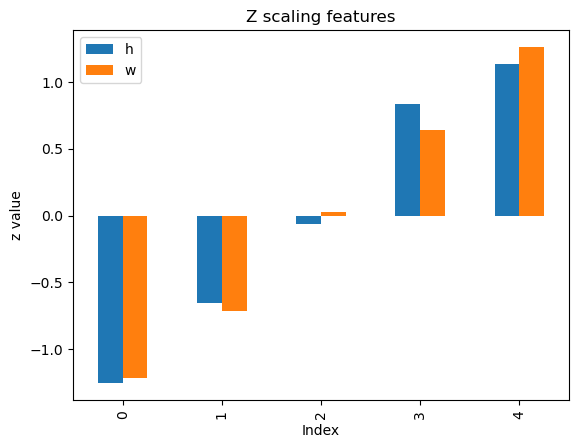

In [14]:
z.plot(kind = 'bar')
plt.title('Z scaling features')
plt.xlabel('Index'); plt.ylabel('z value')
plt.show()

### Min Max Scaling

In [15]:
# Step 1: Min, Max and Range
mn = df.min()
mx = df.max()
rg = mx - mn
mn, mx, rg

(h    150
 w     50
 dtype: int64,
 h    190
 w     90
 dtype: int64,
 h    40
 w    40
 dtype: int64)

In [16]:
# Step 2: Shit to zero
ss = df - mn
ss.head()

,h,w
0,0,0
1,10,8
2,20,20
3,35,30
4,40,40


In [17]:
mm = ss / rg
mm.round(2)

,h,w
0,0.00,0.00
1,0.25,0.20
2,0.50,0.50
3,0.88,0.75
4,1.00,1.00


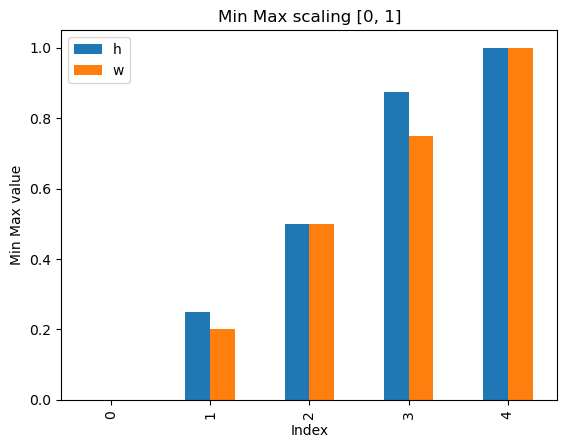

In [19]:
mm.plot(kind = 'bar')
plt.title('Min Max scaling [0, 1]')
plt.xlabel('Index'); plt.ylabel('Min Max value')
plt.show()

### Robust Scaling

In [22]:
df = pd.DataFrame({
    'h': [150, 160, 170, 180, 300],
    'w': [50, 60, 70, 80, 200]
})
df

,h,w
0,150,50
1,160,60
2,170,70
3,180,80
4,300,200


In [24]:
# step 1: median, quartiles, IQR
md = df.median()
q1 = df.quantile(.25)
q3 = df.quantile(.75)

iqr = q3 - q1
md, q1, q3, iqr

(h    170.0
 w     70.0
 dtype: float64,
 h    160.0
 w     60.0
 Name: 0.25, dtype: float64,
 h    180.0
 w     80.0
 Name: 0.75, dtype: float64,
 h    20.0
 w    20.0
 dtype: float64)

In [25]:
# Step 2: center by median
ct = df - md
ct

,h,w
0,-20.0,-20.0
1,-10.0,-10.0
2,0.0,0.0
3,10.0,10.0
4,130.0,130.0


In [26]:
# step 3: divide by IQR
rb = ct/iqr
rb.round(2)

,h,w
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,6.5,6.5


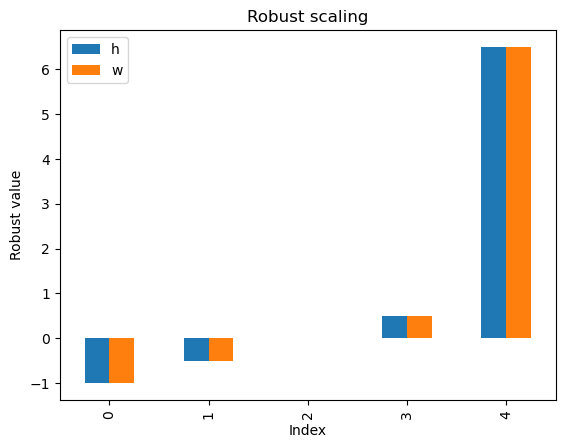

In [27]:
rb.plot(kind = 'bar')
plt.title('Robust scaling')
plt.xlabel('Index'); plt.ylabel('Robust value')
plt.show()

### One hot encoding

In [16]:
df = pd.DataFrame({
    'id': [1, 2, 3, 4],
    'color': ['red' , 'blue', 'green', 'red'],
    'size': ['small', 'medium', 'large', 'small'],
    'price': [10, 12, 15, 11]
})
df

,id,color,size,price
0,1,red,small,10
1,2,blue,medium,12
2,3,green,large,15
3,4,red,small,11


In [21]:
d_color = pd.get_dummies(df['color'], prefix='color', dtype=int)
df_encoded = pd.concat([df, d_color], axis=1)
df_encoded = df_encoded.drop('color', axis=1)
df_encoded

,id,size,price,color_blue,color_green,color_red
0,1,small,10,0,0,1
1,2,medium,12,1,0,0
2,3,large,15,0,1,0
3,4,small,11,0,0,1


### Ordinal Encoding

In [24]:
order = {'small': 1, 'medium': 2, 'large': 3}
df['size'] = df['size'].map(order).astype(int)
df

,id,color,size,price
0,1,red,1,10
1,2,blue,2,12
2,3,green,3,15
3,4,red,1,11


## Understanding Vectors, dot products, and norms

In [26]:
a = np.array([2, 1, 3])
b = np.array([1, 3, 3])
print(a)
print(b)

[2 1 3]
[1 3 3]


### Vector operations (addition and substraction)

In [27]:
add_ab = a + b
sub_ab = a - b

add_ab, sub_ab

(array([3, 4, 6]), array([ 1, -2,  0]))

### Dot Product --> Similarity of direction

In [28]:
dot_ab = a@b
dot_ab

np.int64(14)

## Norms(Length or magnitude of a vector)

In [35]:
l2_a = np.linalg.norm(a)
l1_a = np.linalg.norm(a, ord=1)
l2_a, l1_a

(np.float64(3.7416573867739413), np.float64(6.0))

### Normalising a value

In [39]:
unit_a = a/np.linalg.norm(a)
len_unit_a = np.linalg.norm(unit_a)
unit_a, len_unit_a

(array([0.53452248, 0.26726124, 0.80178373]), np.float64(1.0))

### Distances

In [44]:
X = np.array([
    [70, 80],  # S1
    [60, 90],  # S2
    [85, 60],  # S3
    [78, 76],  # S4
    [62, 65],  # S5
], dtype=float)

q = np.array([75, 70], dtype=float)
eu = np.linalg.norm(X - q, axis=1)
print('Euclidean:', np.round(eu, 3).tolist())

Euclidean: [11.18, 25.0, 14.142, 6.708, 13.928]


In [45]:
ma = np.linalg.norm(X - q, ord=1, axis=1)
print('Euclidean:', np.round(ma, 3).tolist())

Euclidean: [15.0, 35.0, 20.0, 9.0, 18.0]
